In [6]:
import ecole
import numpy as np
import matplotlib.pyplot as plt

In [7]:
def measure_density(instance_generator, n_samples=5):
    """Use a Branching environment to reach a branching node, then read the
    bipartite observation to measure constraint-matrix density."""
    env = ecole.environment.Branching(
        observation_function=ecole.observation.NodeBipartite(),
    )

    densities = []
    for i, instance in enumerate(instance_generator):
        if i >= n_samples:
            break

        obs, action_set, _, done, _ = env.reset(instance)
        if done or obs is None:
            print(f"  Sample {i}: solved at root (no branching node)")
            continue

        n_vars = obs.variable_features.shape[0]
        n_cons = obs.row_features.shape[0]
        n_edges = obs.edge_features.indices.shape[1]
        density = n_edges / (n_vars * n_cons)
        densities.append(density)

        print(f"  Sample {i}: {n_vars} vars, {n_cons} cons, "
              f"{n_edges} edges, density={density:.2%}")

    return densities

### Baseline: default parameters per problem type

In [8]:
baseline_generators = {
    'SetCover': ecole.instance.SetCoverGenerator(n_rows=500, n_cols=1000),
    'CombinatorialAuction': ecole.instance.CombinatorialAuctionGenerator(n_items=100, n_bids=500),
    'IndependentSet': ecole.instance.IndependentSetGenerator(n_nodes=500),
    # CapacitatedFacilityLocationGenerator — segfaults in ecole 0.8.1 osx-arm64 build.
    # Include in generation scripts for use on other machines (linux, colab).
}

baseline_results = {}
for name, gen in baseline_generators.items():
    print(f"\n{name}:")
    densities = measure_density(gen, n_samples=10)
    if densities:
        baseline_results[name] = densities
        print(f"  Average density: {np.mean(densities):.2%}")


SetCover:
  Sample 0: 366 vars, 574 cons, 31600 edges, density=15.04%
  Sample 1: 235 vars, 543 cons, 11901 edges, density=9.33%
  Sample 2: 192 vars, 540 cons, 9227 edges, density=8.90%
  Sample 3: 410 vars, 536 cons, 22278 edges, density=10.14%
  Sample 4: 339 vars, 548 cons, 21131 edges, density=11.37%
  Sample 5: 339 vars, 544 cons, 19920 edges, density=10.80%
  Sample 6: 312 vars, 538 cons, 16925 edges, density=10.08%
  Sample 7: 203 vars, 536 cons, 9645 edges, density=8.86%
  Sample 8: 182 vars, 545 cons, 9596 edges, density=9.67%
  Sample 9: 165 vars, 544 cons, 9365 edges, density=10.43%
  Average density: 10.46%

CombinatorialAuction:
  Sample 0: 383 vars, 237 cons, 7819 edges, density=8.61%
  Sample 1: 409 vars, 217 cons, 8925 edges, density=10.06%
  Sample 2: 345 vars, 225 cons, 7497 edges, density=9.66%
  Sample 3: 429 vars, 243 cons, 10490 edges, density=10.06%
  Sample 4: 395 vars, 226 cons, 7387 edges, density=8.27%
  Sample 5: 381 vars, 218 cons, 7643 edges, density=9.2

### Parameter sweep: tuning sparsity

Each generator exposes parameters that affect the resulting constraint matrix density.
We test sparser configurations to find good candidates for benchmarking.

In [9]:
sweep_generators = {
    # SetCover: density parameter directly controls constraint matrix sparsity
    'SetCover d=0.05 (default)': ecole.instance.SetCoverGenerator(n_rows=500, n_cols=1000, density=0.05),
    'SetCover d=0.02':           ecole.instance.SetCoverGenerator(n_rows=500, n_cols=1000, density=0.02),
    'SetCover d=0.01':           ecole.instance.SetCoverGenerator(n_rows=500, n_cols=1000, density=0.01),

    # IndependentSet: affinity controls edges per new node in Barabasi-Albert
    'IndepSet affinity=4 (default)': ecole.instance.IndependentSetGenerator(n_nodes=500, affinity=4),
    'IndepSet affinity=2':           ecole.instance.IndependentSetGenerator(n_nodes=500, affinity=2),

    # IndependentSet: Erdos-Renyi with tunable edge probability
    'IndepSet ER p=0.25': ecole.instance.IndependentSetGenerator(
        n_nodes=500,
        graph_type=ecole.instance.IndependentSetGenerator.GraphType.erdos_renyi,
        edge_probability=0.25,
    ),
    'IndepSet ER p=0.05': ecole.instance.IndependentSetGenerator(
        n_nodes=500,
        graph_type=ecole.instance.IndependentSetGenerator.GraphType.erdos_renyi,
        edge_probability=0.05,
    ),

    # CombinatorialAuction: add_item_prob controls bundle sizes
    'CombAuction default':          ecole.instance.CombinatorialAuctionGenerator(n_items=100, n_bids=500),
    'CombAuction add_item=0.3':     ecole.instance.CombinatorialAuctionGenerator(n_items=100, n_bids=500, add_item_prob=0.3),
    'CombAuction add_item=0.3 sub=2': ecole.instance.CombinatorialAuctionGenerator(
        n_items=200, n_bids=500, add_item_prob=0.3, max_n_sub_bids=2,
    ),
}

sweep_results = {}
for name, gen in sweep_generators.items():
    print(f"\n{name}:")
    densities = measure_density(gen, n_samples=5)
    if densities:
        sweep_results[name] = densities
        print(f"  Average density: {np.mean(densities):.2%}")


SetCover d=0.05 (default):
  Sample 0: 340 vars, 545 cons, 20612 edges, density=11.12%
  Sample 1: 220 vars, 549 cons, 12914 edges, density=10.69%
  Sample 2: 263 vars, 552 cons, 16590 edges, density=11.43%
  Sample 3: 262 vars, 540 cons, 13922 edges, density=9.84%
  Sample 4: 319 vars, 535 cons, 16574 edges, density=9.71%
  Average density: 10.56%

SetCover d=0.02:
  Sample 0: 549 vars, 534 cons, 20482 edges, density=6.99%
  Sample 1: 226 vars, 490 cons, 7768 edges, density=7.01%
  Sample 2: 329 vars, 553 cons, 12957 edges, density=7.12%
  Sample 3: 471 vars, 530 cons, 15689 edges, density=6.28%
  Sample 4: 225 vars, 486 cons, 7409 edges, density=6.78%
  Average density: 6.84%

SetCover d=0.01:
  Sample 0: solved at root (no branching node)
  Sample 1: 226 vars, 333 cons, 8027 edges, density=10.67%
  Sample 2: 293 vars, 418 cons, 6143 edges, density=5.02%
  Sample 3: solved at root (no branching node)
  Sample 4: 214 vars, 317 cons, 6397 edges, density=9.43%
  Average density: 8.37%


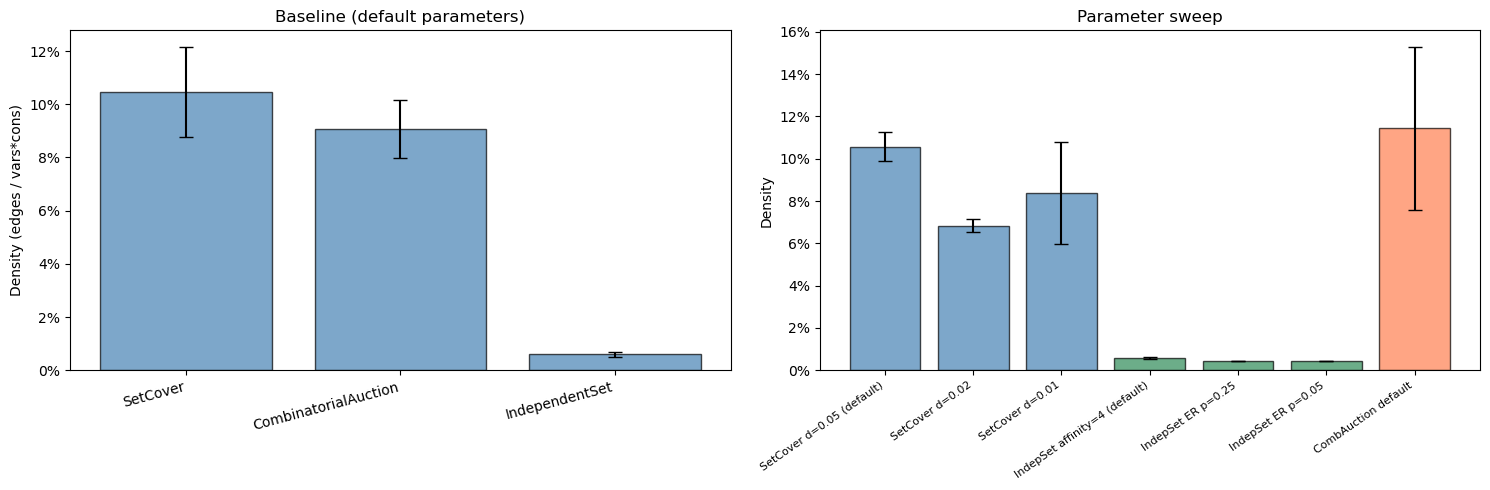

In [10]:
# Combined plot: baseline (left) + parameter sweep (right)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Baseline
names = list(baseline_results.keys())
for pos, name in enumerate(names):
    vals = baseline_results[name]
    ax1.bar(pos, np.mean(vals), yerr=np.std(vals), capsize=5,
            color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_xticks(range(len(names)))
ax1.set_xticklabels(names, rotation=15, ha='right')
ax1.set_ylabel('Density (edges / vars*cons)')
ax1.set_title('Baseline (default parameters)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Sweep
names = list(sweep_results.keys())
colors = []
for n in names:
    if n.startswith('SetCover'):
        colors.append('steelblue')
    elif n.startswith('IndepSet'):
        colors.append('seagreen')
    else:
        colors.append('coral')

for pos, (name, c) in enumerate(zip(names, colors)):
    vals = sweep_results[name]
    ax2.bar(pos, np.mean(vals), yerr=np.std(vals), capsize=5,
            color=c, alpha=0.7, edgecolor='black')
ax2.set_xticks(range(len(names)))
ax2.set_xticklabels(names, rotation=35, ha='right', fontsize=8)
ax2.set_ylabel('Density')
ax2.set_title('Parameter sweep')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.show()

### Findings and recommended generation commands

| Problem | Config | Observed density | Notes |
|---------|--------|-----------------|-------|
| SetCover | `d=0.02` (500×1000) | ~7% | Good balance of sparsity and branching |
| SetCover | `d=0.01` (500×1000) | unreliable | Frequent root-solves — scale up to 1000×2000 |
| IndepSet | BA `affinity=4` | ~0.6% | Very sparse; best behaved |
| IndepSet | BA `affinity=2` | N/A | Solved at root every time — don't use |
| IndepSet | ER `p=0.05` | ~0.4% | Sparse but huge constraint count (~6700) |
| CombAuction | default (`add_item=0.65`) | ~9-11% | Works reliably |
| CombAuction | `add_item=0.3` | N/A | Solved at root — keep `add_item_prob >= 0.55` |

**Data generation commands** (all output to `data/<problem>_samples.pkl` by default):
```bash
# SetCover — baseline training set
python src/data_collection.py --problem setcover --density 0.02

# SetCover — sparser, larger instances
python src/data_collection.py --problem setcover --density 0.01 --n_rows 1000 --n_cols 2000

# IndependentSet — very sparse
python src/data_collection.py --problem indepset --n_nodes 1000

# CombinatorialAuction — moderate density
python src/data_collection.py --problem combauction

# Facility (linux/colab only — segfaults on osx-arm64 ecole 0.8.1)
python src/data_collection.py --problem facility --n_customers 200 --n_facilities 100
```

### Verify: exact configs used by `data_collection.py`

These match the script defaults — the parameters we will actually generate training data with.

In [ ]:
# Exact defaults from data_collection.py
generation_configs = {
    'SetCover (d=0.02, 500x1000)': ecole.instance.SetCoverGenerator(
        n_rows=500, n_cols=1000, density=0.02, max_coef=100),
    'IndepSet (n=1000, aff=4)': ecole.instance.IndependentSetGenerator(
        n_nodes=1000, affinity=4),
    'CombAuction (100 items, 500 bids)': ecole.instance.CombinatorialAuctionGenerator(
        n_items=100, n_bids=500, add_item_prob=0.65),
}

gen_results = {}
for name, gen in generation_configs.items():
    print(f"\n{name}:")
    densities = measure_density(gen, n_samples=10)
    if densities:
        gen_results[name] = densities
        print(f"  Average density: {np.mean(densities):.2%}  "
              f"(std: {np.std(densities):.2%}, n={len(densities)}/10 branched)")

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
names = list(gen_results.keys())
colors = ['steelblue', 'seagreen', 'coral']
for pos, (name, c) in enumerate(zip(names, colors)):
    vals = gen_results[name]
    ax.bar(pos, np.mean(vals), yerr=np.std(vals), capsize=5,
           color=c, alpha=0.7, edgecolor='black')
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('Density (edges / vars*cons)')
ax.set_title('Generation configs (data_collection.py defaults)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.show()